# Cell Analysis Pipeline

Analysis of time-lapse phase-contrast image stacks of round cells/bacteria.

| Step | Description |
|------|-------------|
| 1 | Load image stack |
| 2 | Detect cells in frame 0 using Cellpose |
| 3 | Visualize detections (red X on each cell) |
| 4 | Detect across all frames *(scaffold)* |
| 5 | Track cells over time *(scaffold)* |
| 6 | Statistics and plots *(scaffold)* |
| 7 | Export results *(scaffold)* |

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile

from cell_analysis.segmentation import detect_cells_frame, detect_cells_stack
from cell_analysis.tracking import labels_to_detections, track_cells, compute_track_stats
from cell_analysis.io import save_results

%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Load Image Stack

In [2]:
STACK_PATH = "../data/raw/Gradient-0011.zvi  Ch0.tif"

stack = tifffile.imread(STACK_PATH)
print(f"Stack shape: {stack.shape}")
print(f"  Frames: {stack.shape[0]}")
print(f"  Size:   {stack.shape[2]} x {stack.shape[1]}")
print(f"  Dtype:  {stack.dtype}")

Stack shape: (25, 1040, 1388)
  Frames: 25
  Size:   1388 x 1040
  Dtype:  uint16


### Preview: first frame

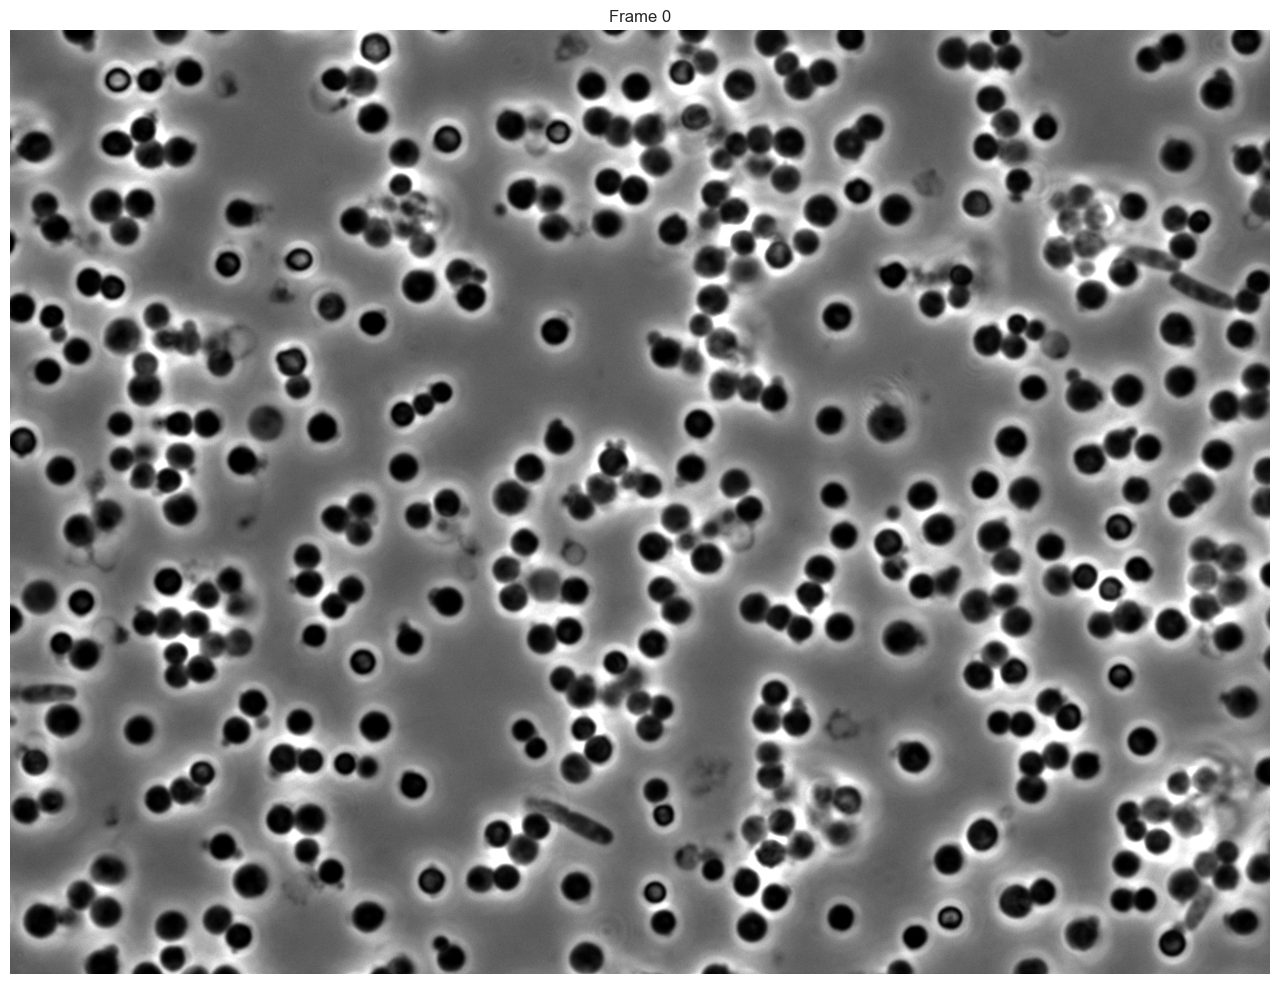

In [3]:
f0 = stack[0]
p1, p99 = np.percentile(f0, [1, 99])

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(f0, cmap="gray", vmin=p1, vmax=p99)
ax.set_title("Frame 0")
ax.axis("off")
plt.tight_layout()

## 2. Detect Cells in Frame 0

### Method comparison

Two detection methods were tested on this data:

| | Classical | Cellpose (deep learning) |
|---|---|---|
| **How it works** | Invert + Gaussian blur + peak detection + watershed + circularity/area/intensity filter | Neural network trained on cell images; image is inverted then fed to the model |
| **Cells found** | 340 | 415 |
| **False positives** | Many — red marks on empty halo regions and background | Very few — almost all marks land on actual cells |
| **Centroid accuracy** | Often shifted from true cell center | Precisely centered |
| **Adjacent cells** | Struggles to separate touching cells | Handles them well |
| **Speed** | Fast (seconds) | Slower (~1 min/frame on CPU, first run downloads ~1 GB model) |
| **Dependencies** | Only scikit-image, scipy | Requires cellpose + PyTorch |

**Verdict: Cellpose is significantly better for this data.** The classical
method produces too many false positives in the bright halo regions between
cells, and its centroids are often shifted. Cellpose accurately segments
individual cells even when they are touching, and its centroids land
precisely on cell centers.

The classical method is still available as `detect_cells_frame_classical()`
in the segmentation module if you need a quick, dependency-light fallback.

> **First run:** downloads the Cellpose model (~1 GB). Subsequent runs use the cache.

In [4]:
# Cellpose detection parameters (tuned for this dataset).
# - diameter=32: median cell diameter from auto-detection. Setting it
#   explicitly skips auto-detection and speeds up each frame.
# - min_area=200: reject tiny specks that Cellpose occasionally segments.
# - min_circularity=0.7: reject elongated objects (rod-shaped bacteria,
#   debris). Round cells in this dataset have circularity 0.7-1.0
#   (median 0.93); elongated objects fall below 0.7.
# - gpu=False: no CUDA on this Mac (Apple Silicon MPS not yet
#   supported by Cellpose).
DETECT_PARAMS = dict(
    diameter=32,
    min_area=200,
    min_circularity=0.7,
    gpu=False,
)

centroids, labels = detect_cells_frame(f0, **DETECT_PARAMS)
print(f"Detected {len(centroids)} cells in frame 0")

/Users/vvetshte/Projects/temp/experiments_image/.venv/lib/python3.11/site-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),


Detected 404 cells in frame 0


## 3. Visualize: Frame 0 with detected cells

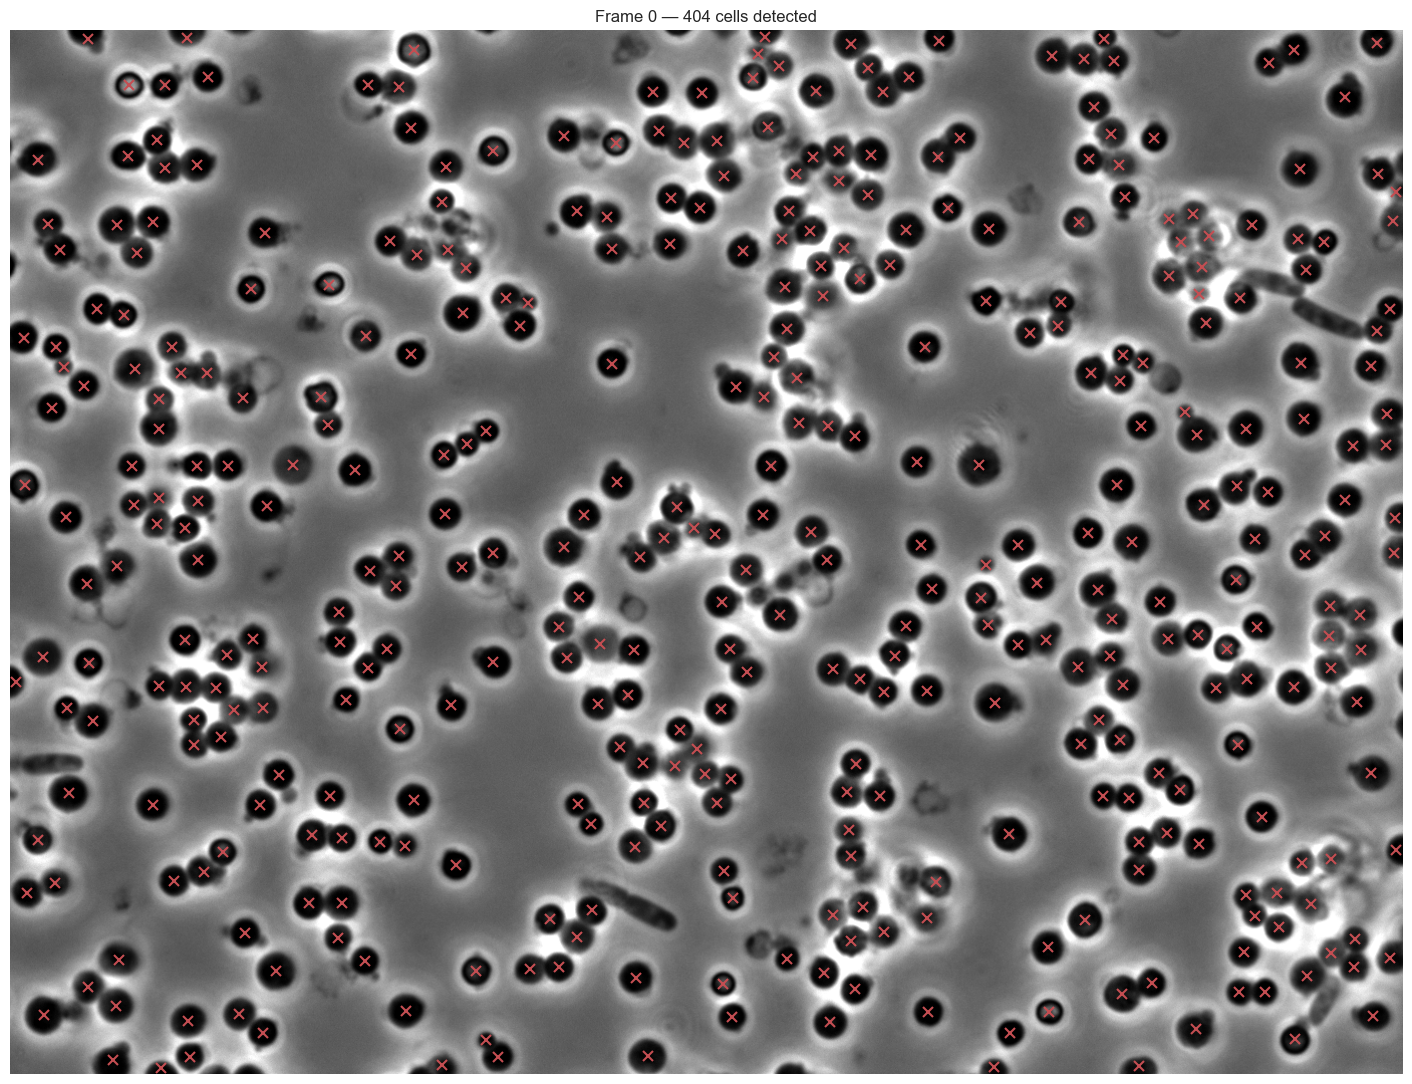

In [5]:
fig, ax = plt.subplots(figsize=(16, 11))
ax.imshow(f0, cmap="gray", vmin=p1, vmax=p99)
ax.plot(
    centroids[:, 1], centroids[:, 0],
    "rx", markersize=7, markeredgewidth=1.5,
)
ax.set_title(f"Frame 0 \u2014 {len(centroids)} cells detected")
ax.axis("off")
plt.tight_layout()

### Zoomed view (dense region)

Adjust the crop coordinates to inspect different parts of the image.

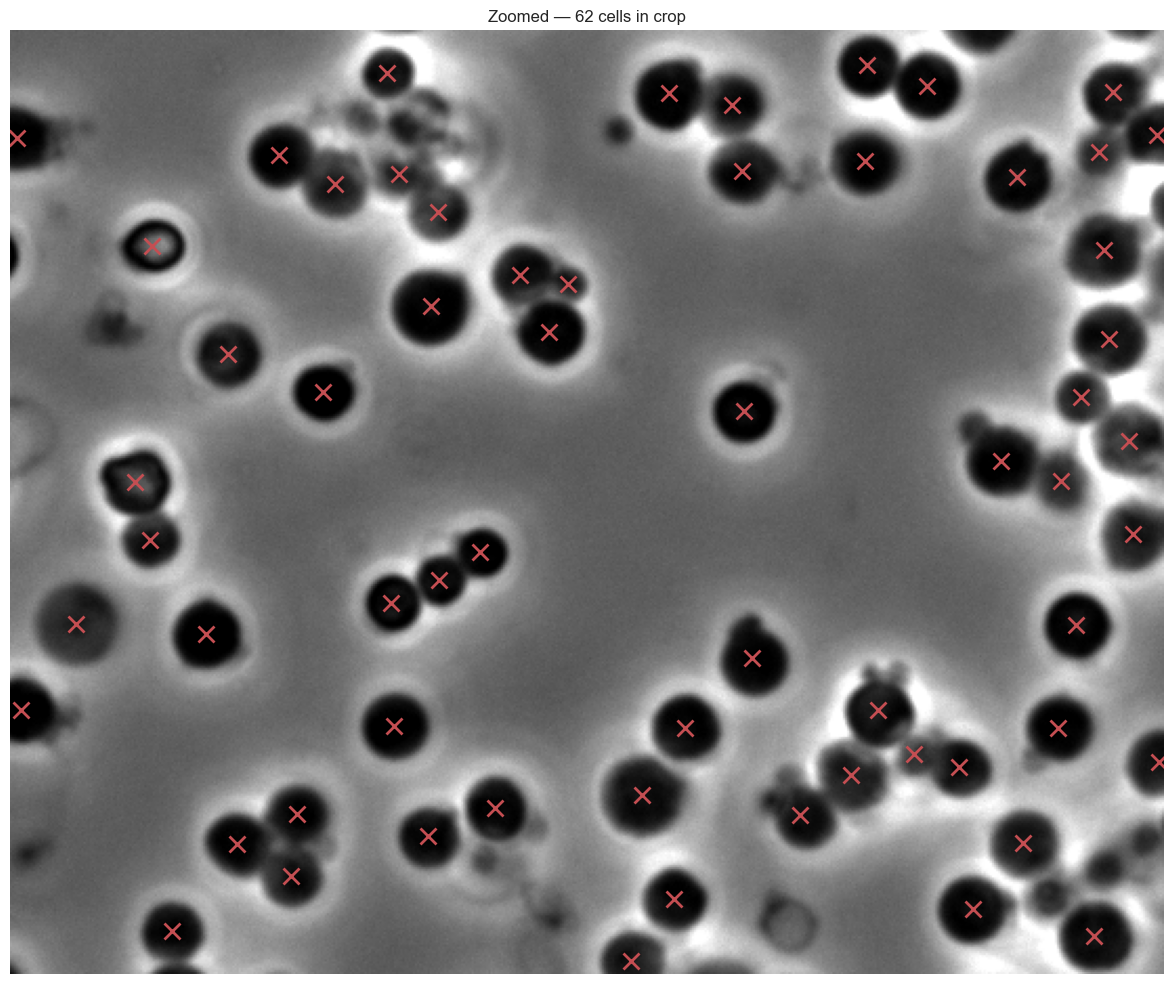

In [6]:
Y_SLICE, X_SLICE = slice(150, 600), slice(250, 800)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(
    f0[Y_SLICE, X_SLICE], cmap="gray", vmin=p1, vmax=p99,
    extent=[X_SLICE.start, X_SLICE.stop, Y_SLICE.stop, Y_SLICE.start],
)

in_crop = (
    (centroids[:, 0] >= Y_SLICE.start) & (centroids[:, 0] < Y_SLICE.stop)
    & (centroids[:, 1] >= X_SLICE.start) & (centroids[:, 1] < X_SLICE.stop)
)
c = centroids[in_crop]
ax.plot(c[:, 1], c[:, 0], "rx", markersize=12, markeredgewidth=2)
ax.set_title(f"Zoomed \u2014 {in_crop.sum()} cells in crop")
ax.axis("off")
plt.tight_layout()

---

## 4. Detect Cells Across All Frames

*Runs Cellpose on each of the 25 frames. This takes several minutes on CPU.*

In [ ]:
centroids_all, label_stack = detect_cells_stack(stack, **DETECT_PARAMS)

## 5. Track Cells Over Time

| Parameter | Description |
|-----------|-------------|
| `search_range` | Max pixels a cell can move between frames |
| `memory` | Frames a cell can vanish and still be re-linked |

In [ ]:
SEARCH_RANGE = 30.0
MEMORY = 3

detections = labels_to_detections(label_stack)
print(f"Total detections across all frames: {len(detections)}")

tracked = track_cells(detections, search_range=SEARCH_RANGE, memory=MEMORY)
print(f"Unique tracks: {tracked['track_id'].nunique()}")

track_stats = compute_track_stats(tracked)
print(f"Cells that disappeared before last frame: {track_stats['disappeared'].sum()}")

## 6. Statistics and Plots

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cells_per_frame = tracked.groupby("frame")["track_id"].nunique()
axes[0].plot(cells_per_frame.index, cells_per_frame.values, "o-")
axes[0].set(xlabel="Frame", ylabel="Cell count", title="Cells detected per frame")

sns.histplot(track_stats["lifetime"], bins=20, ax=axes[1])
axes[1].set(xlabel="Lifetime (frames)", ylabel="Count", title="Track lifetime distribution")

sns.histplot(tracked["area"], bins=30, ax=axes[2])
axes[2].set(xlabel="Area (pixels)", ylabel="Count", title="Cell area distribution")

plt.tight_layout()

### Disappearance events

Cells whose tracks end before the last frame.

In [ ]:
disappeared = track_stats[track_stats["disappeared"]].sort_values("last_frame")
print(f"{len(disappeared)} cells disappeared before the final frame")
disappeared

## 7. Export Results

In [ ]:
save_results(tracked, "../results/tracked_cells.csv")
save_results(track_stats, "../results/track_statistics.csv")
print("Results saved to ../results/")